### Try to get the director field as a curved function $s(z)$.

In [1]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np

# Load data
u = md.Universe('md_1.tpr', 'md_1_noPBC.xtc')
u.trajectory[-1]
protein = u.select_atoms("protein")
backbone = protein.select_atoms("backbone")
xd, yd, zd = u.trajectory[-1].dimensions[0:3]/10

t_eq = 15000 # ps
# Time Data
ti = u.trajectory[0].time
tf = u.trajectory[-1].time
nt = len(u.trajectory)-1
deltat = (tf-ti)/nt
t = np.linspace(ti,tf,nt+1)
mask = (t >= t_eq)

#### Functions

In [2]:
def get_mean_coords_chain(chain, molecule, mask, group):
    mean_coords = None
    chains = protein.fragments[3*molecule:3*molecule + 3]
    chain = chains[chain].select_atoms(group)
    n = 0
    for ts in u.trajectory[mask]:
        coords = chain.positions / 10
        if mean_coords is None:
            mean_coords = coords.astype(float)
            n = 1
        else:
            n += 1
            mean_coords += (coords - mean_coords) / n
    return mean_coords

def line_fun(start, end):
    x1, y1, z1 = start
    x2, y2, z2 = end
    # Slope
    mx = (x2 - x1)/(z2 - z1)
    my = (y2 - y1)/(z2 - z1)
    # Intercept
    bx = x1 - mx*z1
    by = y1 - my*z1

    x_z = lambda z: mx*z + bx
    y_z = lambda z: my*z + by

    return x_z, y_z

def clean_phi(y, x, evalu):
    phi_p = np.atan2(y, x)
    phi_uw = np.unwrap(phi_p[np.argsort(evalu)], discont=np.pi)
    return phi_uw

#### One Molecule (NOT CENTERED)

In [3]:
# Test with a single molecule
mol = 0
chain_means = []

# Get the mean of each chain
for i in range(3):
    chain_means.append(get_mean_coords_chain(i, mol, mask, "backbone"))

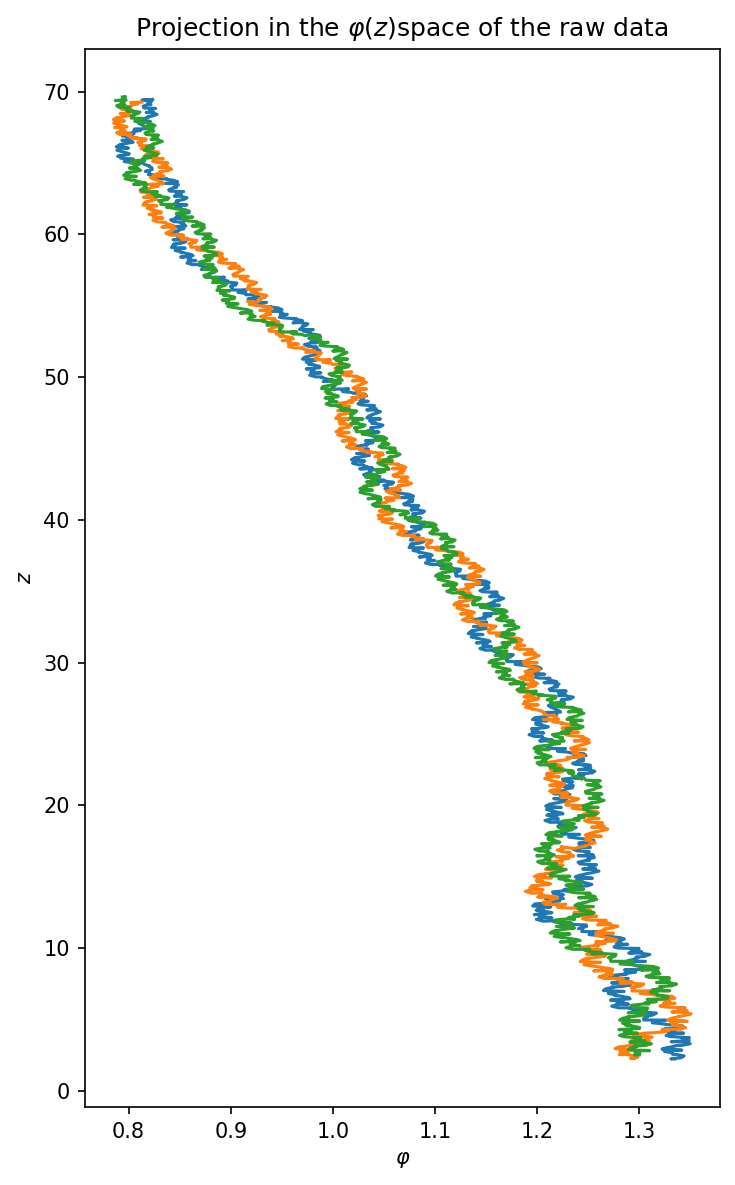

In [4]:
# Not centered yet!

plt.figure(figsize=(5, 8), dpi=150)
for i in range(3):
    chain_coords = chain_means[i]
    phi_chain = np.atan2(chain_coords[:,1], chain_coords[:,0])
    z_chain = chain_coords[:,2]
    plt.plot(phi_chain, z_chain)

plt.title("Projection in the " + r"$\varphi(z)$" + "space of the raw data")
plt.xlabel(r"$\varphi$")
plt.ylabel(r"$z$")
plt.tight_layout()
plt.show()

#### Whole Protein (JUST MEAN)

In [5]:
# Whole Protein
fib_coords = []
# Mean
for ts in u.trajectory[mask]:
    coords = backbone.positions / 10
    fib_coords.append(coords)
fib_mean = np.mean(fib_coords, 0)

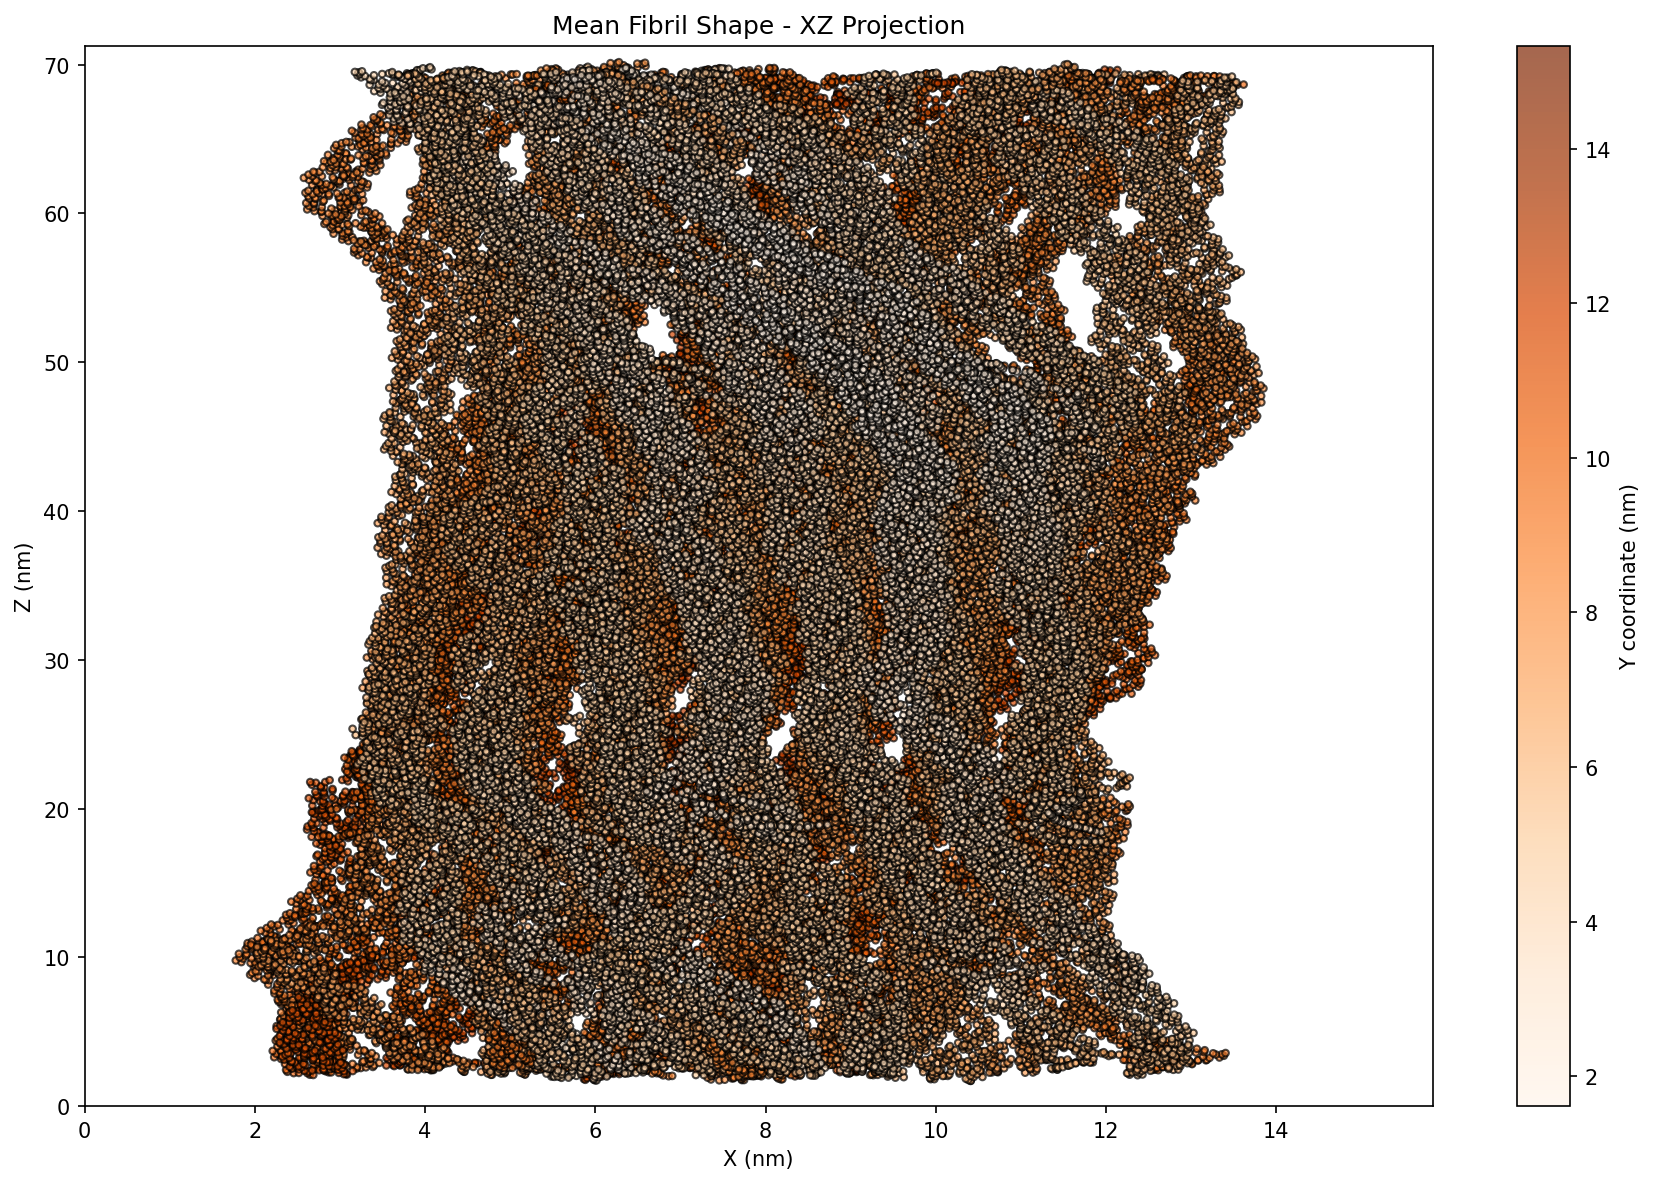

In [6]:
plt.figure(figsize=(12, 8), dpi=150)
sc = plt.scatter(fib_mean[:, 0], fib_mean[:, 2],
                     c=fib_mean[:, 1], cmap='Oranges',
                     s=10, edgecolor='k', alpha=0.7)
plt.colorbar(sc, label='Y coordinate (nm)')

plt.xlabel("X (nm)")
plt.ylabel("Z (nm)")
plt.title("Mean Fibril Shape - XZ Projection")
plt.xlim(0, xd)
plt.ylim(0, zd)
plt.tight_layout()
plt.show()

#### Center of Fibril Computation

Getting the centerline of the fibril

In [7]:
# Centerline Functions
fib_coords = []
for ts in u.trajectory[mask]:
    coords = backbone.positions / 10
    fib_coords.append(coords)
fib_mean = np.mean(fib_coords, 0)
nm_slab = 2
top_slab = fib_mean[fib_mean[:, 2] >= max(fib_mean[:,2]) - nm_slab]
bottom_slab =  fib_mean[fib_mean[:, 2] <= min(fib_mean[:,2]) + nm_slab]
top_vec = np.array([np.mean(top_slab[:, 0]), np.mean(top_slab[:, 1]), max(fib_mean[:,2])])
low_vec = np.array([np.mean(bottom_slab[:, 0]), np.mean(bottom_slab[:, 1]), min(fib_mean[:,2])])
x_cf, y_cf = line_fun(low_vec, top_vec)

#### One Molecule Centered $r$: CENTERLINE AND $r,\varphi, z$

Getting the mean backbone atoms position through $t \in [\tau_s, t_f]$

In [24]:
# Molecule
mol = 14
chain_means = []
for i in range(3):
    chain_means.append(get_mean_coords_chain(i, mol, mask, "backbone"))

Computing:
$$
\varphi(z)=\arctan\left(\frac{y_\text{backbones}(z) - y_\text{center}(z)}{x_\text{backbones}(z) - x_\text{center}(z)} \right)
$$

Geting a linear fit of the form:
$$
\varphi(z)=\tau z + \varphi_0
$$

And getting the radius such as:
$$
r(z) = \sqrt{(y_\text{backbones}(z) - y_\text{center}(z))^2 + (x_\text{backbones}(z) - x_\text{center}(z))^2}
$$

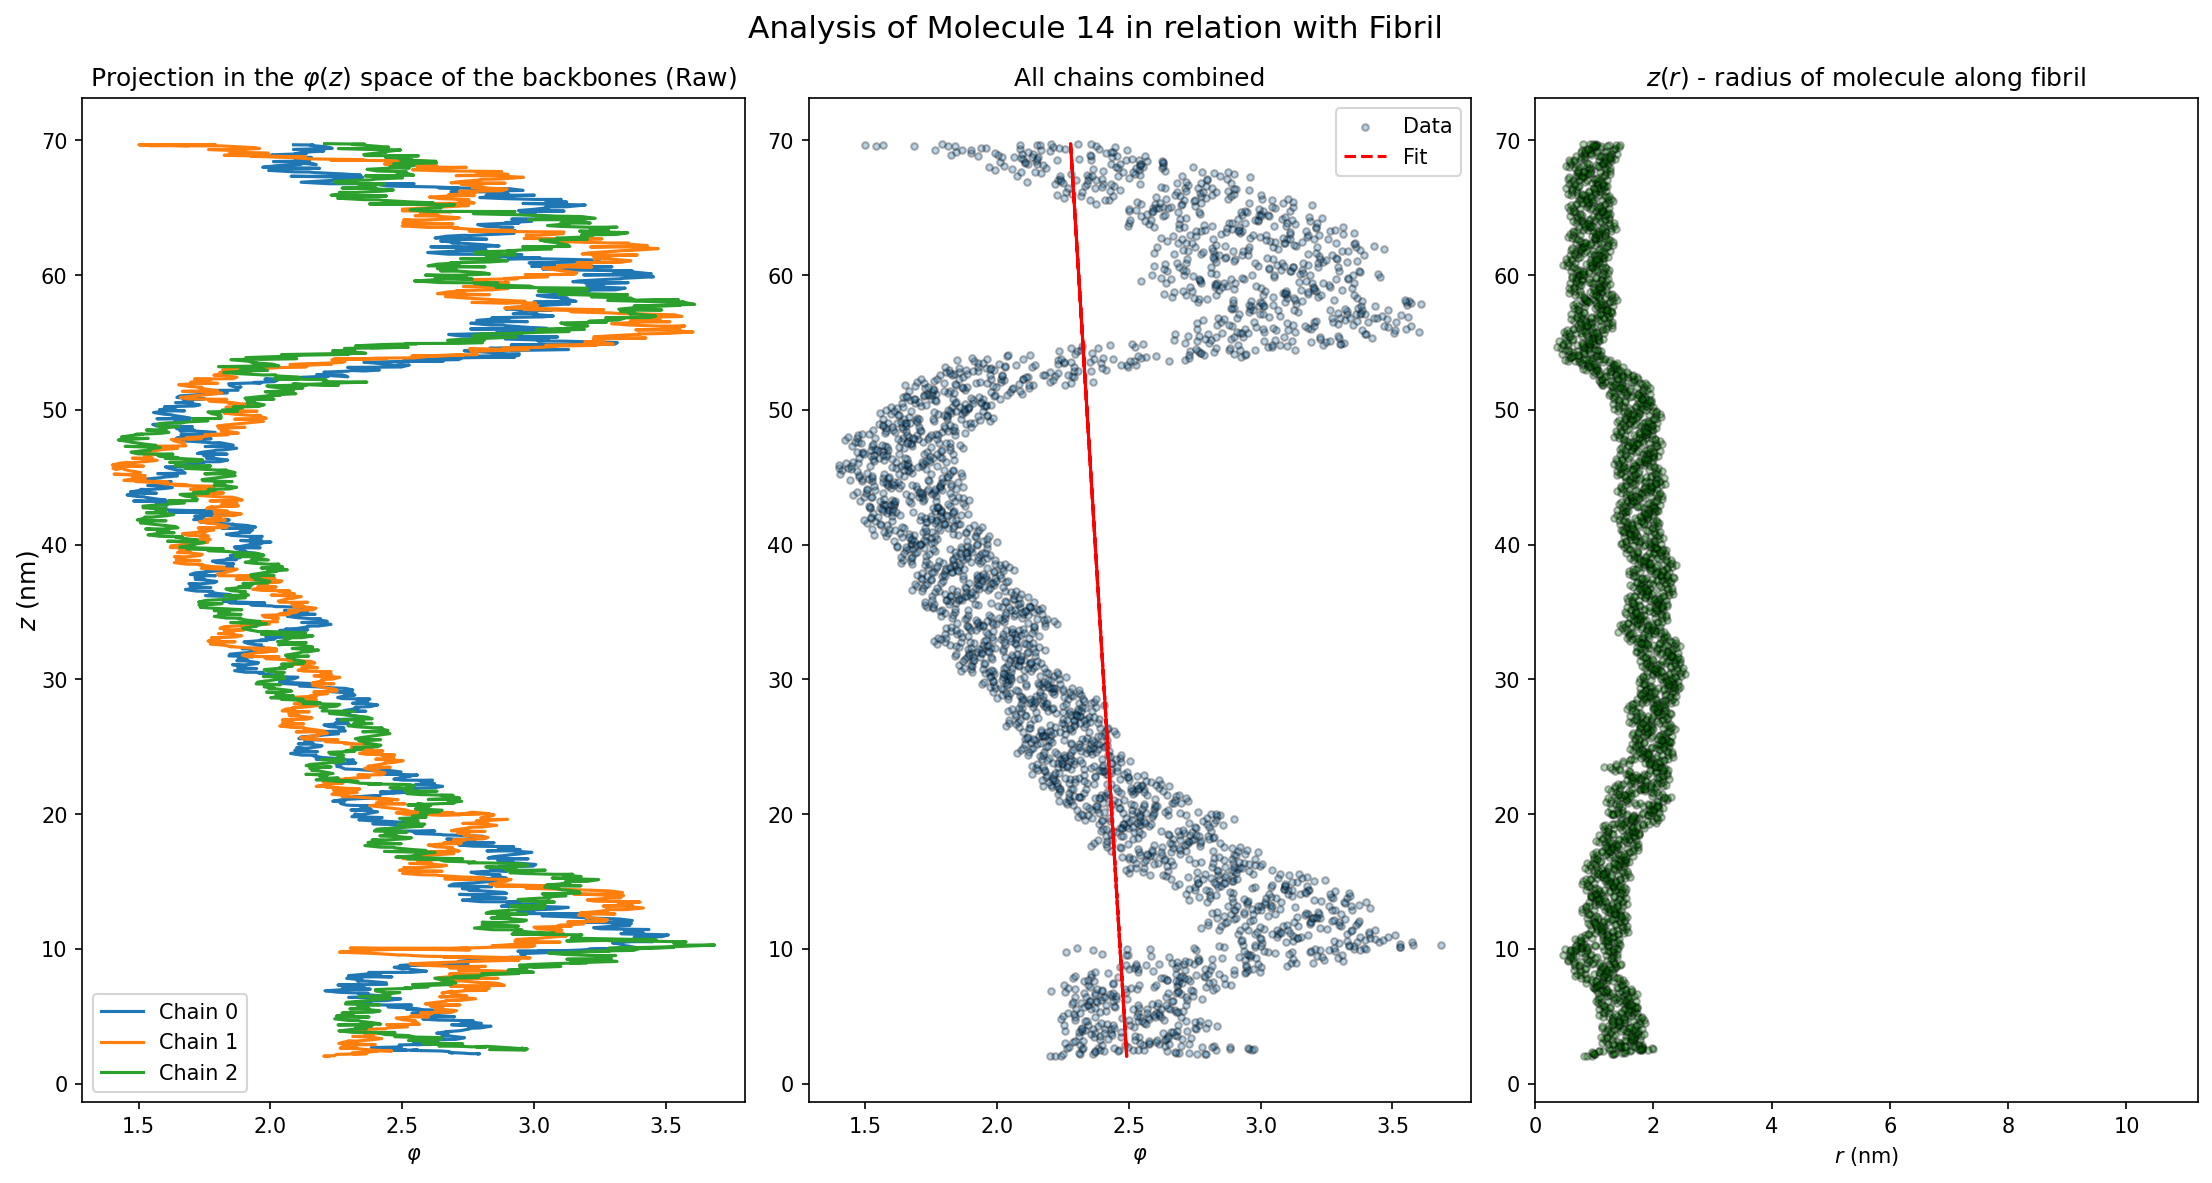

In [25]:
fig, axs =  plt.subplots(1, 3, figsize=(15, 8), dpi=150)

radius_all = []
phi_all = []
z_all = []
# --- Left: original per-chain plot ---
for i in range(3):
    chain_coords = chain_means[i]
    z_chain = chain_coords[:, 2]
    # phi_chain = np.atan2(chain_coords[:, 1] - y_cf(z_chain), chain_coords[:, 0] - x_cf(z_chain))
    phi_chain = clean_phi(chain_coords[:, 1] - y_cf(z_chain), chain_coords[:, 0] - x_cf(z_chain), z_chain)
    r_chain = np.sqrt((chain_coords[:, 1] - y_cf(z_chain))**2 + (chain_coords[:, 0] - x_cf(z_chain))**2)
    radius_all.append(r_chain)
    phi_all.append(phi_chain)
    z_all.append(z_chain)
    axs[0].plot(phi_chain, z_chain, label=f"Chain {i}")
axs[0].set_title("Projection in the " + r"$\varphi(z)$" + " space of the backbones (Raw)")
axs[0].set_xlabel(r"$\varphi$")
axs[0].legend()

# --- Right: combined scatter of all chains ---
# Flatten Lists
radius_all = [element for sublist in radius_all for element in sublist]
phi_all = [element for sublist in phi_all for element in sublist]
z_all = [element for sublist in z_all for element in sublist]

axs[1].scatter(phi_all, z_all, s=10, edgecolor='k', alpha=0.3, label="Data")

# Make a linear fit
m, b = np.polyfit(z_all, phi_all, 1)
fit = np.poly1d((m, b))
axs[1].plot(fit(z_all), z_all, linestyle='dashed', color='r', label="Fit")

axs[1].set_title("All chains combined")
axs[1].set_xlabel(r"$\varphi$")
# axs[1].set_ylabel(r"$z$ (nm)")
# axs[1].set_xlim(-np.pi, np.pi)
axs[1].legend()

# --- Right: radius vs z ---
axs[2].scatter(radius_all, z_all, s=10, color='g', edgecolor='k', alpha=0.3)
axs[2].set_xlabel(r"$r$ (nm)")
# axs[2].set_ylabel(r"$z$ (nm)")
axs[2].set_title(r"$z(r)$ - radius of molecule along fibril")
axs[2].set_xlim(0, np.sqrt(xd**2 + yd**2) / 2)

fig.supylabel(r"$z$ (nm)")
plt.suptitle(f"Analysis of Molecule {mol} in relation with Fibril", fontsize=15)
plt.tight_layout()
plt.show()

**Note:** Molecule 20 is almost straight, leads to bad angle given the center of the fibril. Same with molecule 14. We see it with the closer molecules as they are the ones which are more sensible to any error we could have from the center of the fibril model.

#### Compute all the slopes $\tau$ and $\langle r \rangle$

Based upon the fit for the $\varphi(z)$ function.

In [57]:
tot_mol = int((protein.fragindices[-1] + 1)/3)
tau = np.zeros(tot_mol)
mean_rad = np.zeros(tot_mol)

for mol in range(tot_mol):

    chain_means = []
    radius_all = []
    phi_all = []
    z_all = []

    # Chain Means
    for i in range(3):
        chain_means.append(get_mean_coords_chain(i, mol, mask, "backbone"))
    
    # Cylindrical Coordinates
    for i in range(3):
        chain_coords = chain_means[i]
        z_chain = chain_coords[:, 2]
        phi_chain = clean_phi(chain_coords[:, 1] - y_cf(z_chain), chain_coords[:, 0] - x_cf(z_chain), z_chain)
        r_chain = np.sqrt((chain_coords[:, 1] - y_cf(z_chain))**2 + (chain_coords[:, 0] - x_cf(z_chain))**2)
        radius_all.append(r_chain)
        phi_all.append(phi_chain)
        z_all.append(z_chain)
    
    # Flattening
    radius_all = [element for sublist in radius_all for element in sublist]
    phi_all = [element for sublist in phi_all for element in sublist]
    z_all = [element for sublist in z_all for element in sublist]

    # Tau
    tau[mol], _ = np.polyfit(z_all, phi_all, 1)

    # Mean Radius
    mean_rad[mol] = np.mean(radius_all)


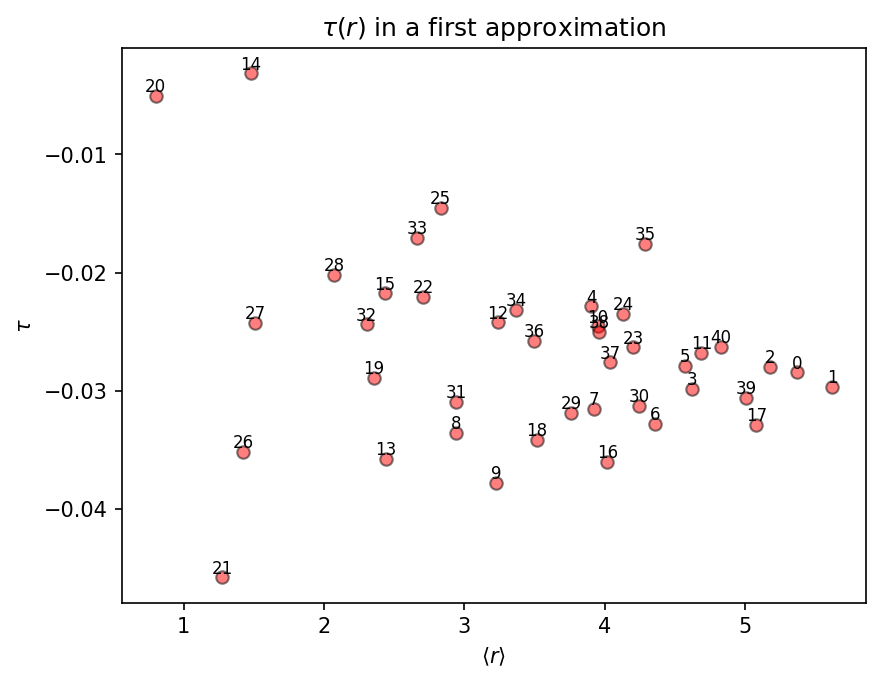

In [66]:
# Plot
plt.figure(dpi=150)
# plt.plot(mean_rad, tau, color='k', linestyle='dashed')
plt.scatter(mean_rad, tau, color='r', edgecolor='k', alpha=0.5)

# Label Molecules
for i, (x, y) in enumerate(zip(mean_rad, tau)):
    plt.text(x, y, str(i), fontsize=8, ha='center', va='bottom')

plt.xlabel(r'$\langle r \rangle$')
plt.ylabel(r'$\tau$')
plt.title(r"$\tau(r)$ in a first approximation")
plt.show()